# Визуализация данных

In [1]:
import pandas as pd
import numpy as np

### Считать в `pandas.DataFrame` любой источник данных: CSV, JSON, Excel-файл, HTML-таблицу и т.п.
Также можно сконвертировать в DataFrame любой из встроенных датасетов `sklearn`: (см. [инструкцию](https://stackoverflow.com/questions/38105539/how-to-convert-a-scikit-learn-dataset-to-a-pandas-dataset)).  

   > Главное условие к датасету, который вы загружаете &ndash; там должны быть как минимум пара числовых колонок и как минимум одна категориальная с небольшим числом категорий.

In [2]:
# Загрузка датасета
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Просмотр структуры данных
print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
df.head()

Размер датасета: (891, 12)

Первые 5 строк:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Привести описание датасета.  

В качестве датасета взял датасет с инфорацией о пассажирах Титаника (классика, моя оригинальность устала :D)

Датасет содержит данные о пассажирах лайнера RMS Titanic, цель (целевой признак, таргет) — **прогнозирование выживания пассажира** при крушении судна.

| Признак | Описание | Единицы измерения / Возможные значения |
| --- | --- | --- |
| **PassengerId** | Уникальный идентификатор пассажира | Целое число (1–891) |
| **Survived** | Факт выживания (целевая переменная) | `0` — не выжил, `1` — выжил |
| **Pclass** | Класс билета (прокси для социально-экономического статуса) | `1` — первый класс (верхний), `2` — второй (средний), `3` — третий (нижний) |
| **Name** | Полное имя пассажира | Строка (включает титулы, фамилии, имена) |
| **Sex** | Пол пассажира | `male`, `female` |
| **Age** | Возраст пассажира | Годы (дробные для детей <1 года; оценки округляются до xx.5) |
| **SibSp** | Количество родственников-попутчиков: братьев, сестёр, супругов (включая сводных) | Целое неотрицательное число |
| **Parch** | Количество родителей или детей-попутчиков (мать, отец, дочь, сын, сводные); дети с няней имеют `Parch=0` | Целое неотрицательное число |
| **Ticket** | Номер билета | Строка (может содержать буквы, цифры, разделители) |
| **Fare** | Стоимость билета | Фунты стерлингов (£) |
| **Cabin** | Номер каюты | Строка (буква + номер); много пропущенных значений |
| **Embarked** | Порт посадки | `C` = Cherbourg (Шербур), `Q` = Queenstown (Квинстаун), `S` = Southampton (Саутгемптон) |

In [3]:
print("Информация о столбцах:")
print(df.info())
print("\nСтатистическое описание числовых столбцов:")
df.describe()

Информация о столбцах:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Статистическое описание числовых столбцов:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## matplotlib

- Построить несколько графиков разного вида с использованием `matplotlib`.  
- Построить несколько суб-графиков на одном графике используя `.subplot`.  
- Построить интерактивный график со слайдером.

> - Графики должны быть разных видов.  
> - Хотя бы в одном графике необходимо подписать оси.  
> - Во всех графиках необходимо указать название.
> - Необязательно строить сложный и перегруженный информацией интерактивный график, достаточноодного-двух числовых признаков в разрезе другого признака, как минимум добавить слайдер (ползунок).Наличие других графических элементов управления (кнопки и т.п.) &ndash; опционально.

In [4]:
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14

### Построить несколько графиков разного вида с использованием `matplotlib`.  

#### Круговая диаграмма

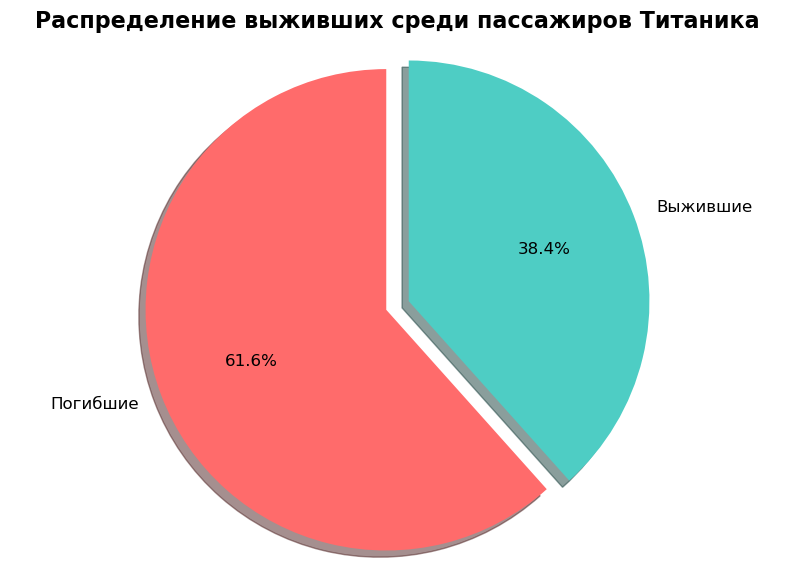

In [5]:
# Круговая диаграмма
plt.figure(figsize=(10, 7))

# Подготовка данных
survival_counts = df['Survived'].value_counts()
labels = ['Погибшие', 'Выжившие']
colors = ['#ff6b6b', '#4ecdc4']
explode = (0.1, 0)  # Выделяем первый сегмент

plt.pie(survival_counts, labels=labels, autopct='%1.1f%%', 
        startangle=90, colors=colors, explode=explode, shadow=True)
plt.title('Распределение выживших среди пассажиров Титаника', fontsize=16, fontweight='bold')
plt.axis('equal')  # Чтобы круг был кругом

plt.show()

Круговая диаграмма показывает общее распределение выживших и погибших пассажиров. Это базовый график, который дает общее представление о балансе классов в наборе данных. На нем видно, что выжило только около 38% пассажиров.

Ну как говорится, если умер 1, то это траур, а если сотни, то это статистика

#### Столбчатая диаграмма

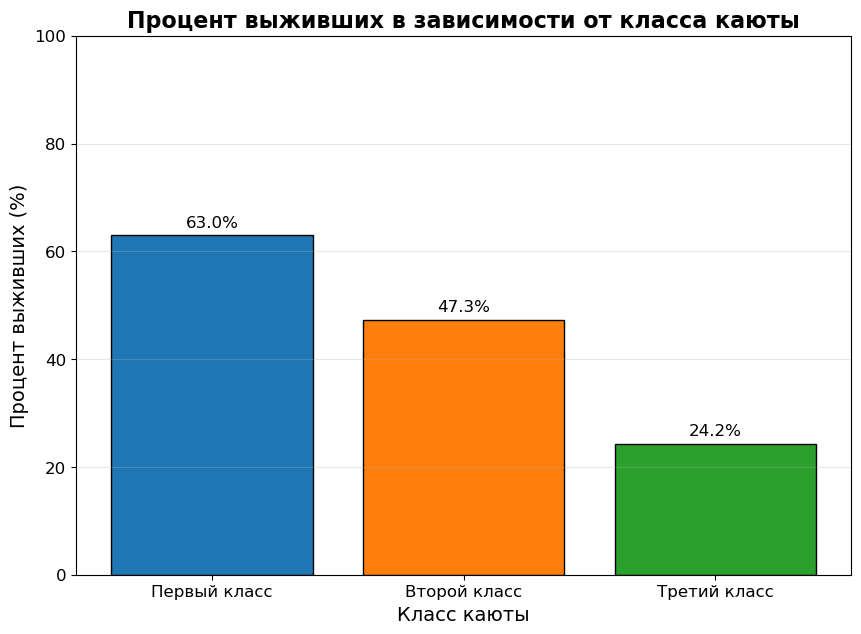

In [6]:
# Столбчатая диаграмма
plt.figure(figsize=(10, 7))

# Группируем данные
class_survival = df.groupby('Pclass')['Survived'].mean() * 100

# Создаем график
bars = plt.bar(class_survival.index, class_survival.values, 
               color=['#1f77b4', '#ff7f0e', '#2ca02c'], edgecolor='black')

# Добавляем значения на столбцы
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=12)

plt.xlabel('Класс каюты', fontsize=14)
plt.ylabel('Процент выживших (%)', fontsize=14)
plt.title('Процент выживших в зависимости от класса каюты', fontsize=16, fontweight='bold')
plt.xticks([1, 2, 3], ['Первый класс', 'Второй класс', 'Третий класс'])
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)

plt.show()

Эта столбчатая диаграмма показывает четкую зависимость между классом каюты и шансом на выживание. Пассажиры первого класса имели значительно больше шансов выжить (63%), чем пассажиры третьего класса (24%).

### Гистограмма

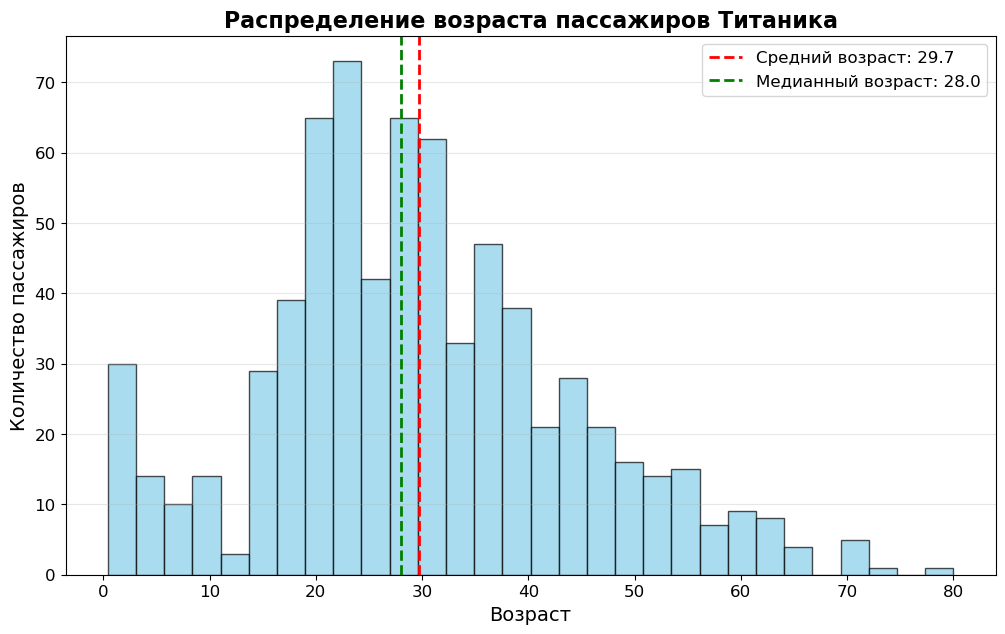

In [7]:
plt.figure(figsize=(12, 7))

# Удаляем пропущенные значения для возраста
age_data = df['Age'].dropna()

# Создаем гистограмму
plt.hist(age_data, bins=30, color='skyblue', edgecolor='black', alpha=0.7)

plt.xlabel('Возраст', fontsize=14)
plt.ylabel('Количество пассажиров', fontsize=14)
plt.title('Распределение возраста пассажиров Титаника', fontsize=16, fontweight='bold')
plt.axvline(age_data.mean(), color='red', linestyle='dashed', linewidth=2, label=f'Средний возраст: {age_data.mean():.1f}')
plt.axvline(age_data.median(), color='green', linestyle='dashed', linewidth=2, label=f'Медианный возраст: {age_data.median():.1f}')

plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

Гистограмма показывает распределение возраста пассажиров. Мы видим, что большинство пассажиров были в возрасте 20-40 лет. Красная и зеленая линии показывают среднее и медианное значения соответственно. Распределение имеет длинный правый хвост, что означает наличие небольшого количества пожилых пассажиров.

#### Линейный график

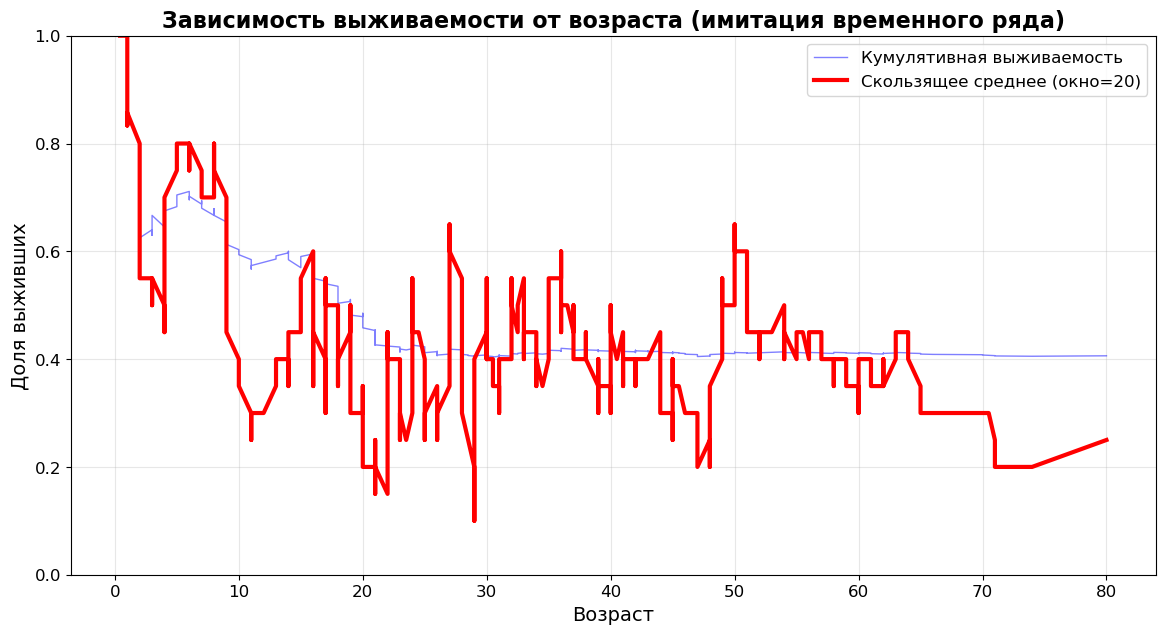

In [8]:
plt.figure(figsize=(14, 7))

# Создаем искусственный временной ряд на основе данных
# Сортируем по возрасту и считаем кумулятивную выживаемость
df_sorted = df.sort_values('Age').dropna(subset=['Age', 'Survived'])
df_sorted['CumulativeSurvival'] = df_sorted['Survived'].expanding().mean()

# Создаем скользящее среднее для сглаживания
window_size = 20
df_sorted['MovingAvg'] = df_sorted['Survived'].rolling(window=window_size, min_periods=1).mean()

# Рисуем линейный график
plt.plot(df_sorted['Age'], df_sorted['CumulativeSurvival'], 
         color='blue', alpha=0.5, linewidth=1, label='Кумулятивная выживаемость')
plt.plot(df_sorted['Age'], df_sorted['MovingAvg'], 
         color='red', linewidth=3, label=f'Скользящее среднее (окно={window_size})')

plt.xlabel('Возраст', fontsize=14)
plt.ylabel('Доля выживших', fontsize=14)
plt.title('Зависимость выживаемости от возраста (имитация временного ряда)', 
          fontsize=16, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(0, 1)

plt.show()

Этот линейный график имитирует временной ряд, показывая как изменяется вероятность выживания с возрастом. Красная линия (скользящее среднее) сглаживает колебания и показывает общий тренд: более высокие шансы на выживание у детей и пожилых людей ("спасали женщин и детей в первую очередь").

#### Диаграмма рассеяния

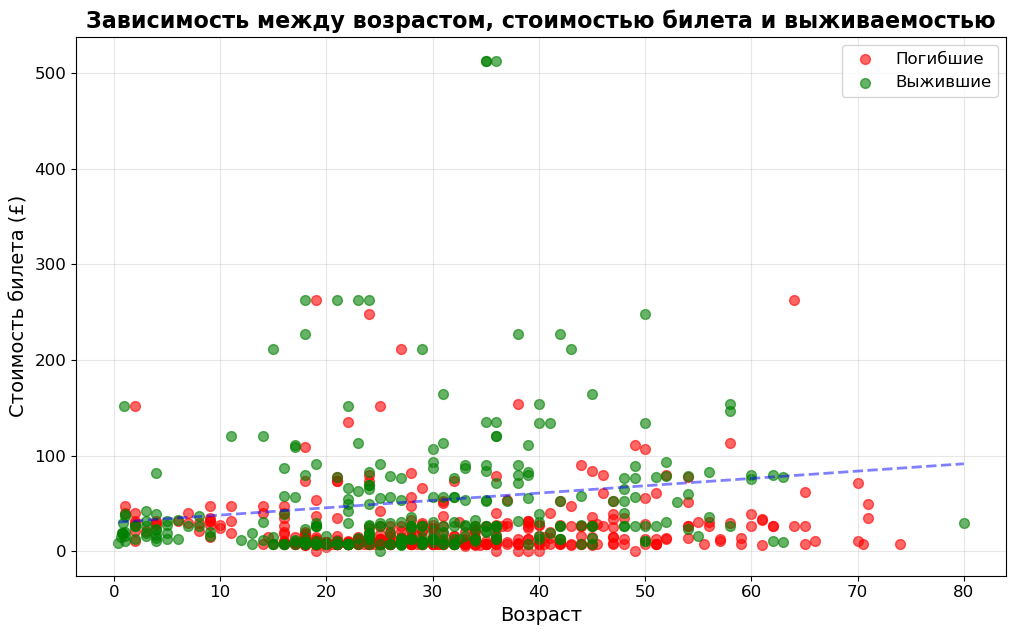

In [9]:
plt.figure(figsize=(12, 7))

# Подготовка данных
scatter_data = df.dropna(subset=['Age', 'Fare'])

# Разделяем по выживаемости для раскраски
survived = scatter_data[scatter_data['Survived'] == 1]
not_survived = scatter_data[scatter_data['Survived'] == 0]

# Создаем scatter plot
plt.scatter(not_survived['Age'], not_survived['Fare'], 
            alpha=0.6, color='red', label='Погибшие', s=50)
plt.scatter(survived['Age'], survived['Fare'], 
            alpha=0.6, color='green', label='Выжившие', s=50)

plt.xlabel('Возраст', fontsize=14)
plt.ylabel('Стоимость билета (£)', fontsize=14)
plt.title('Зависимость между возрастом, стоимостью билета и выживаемостью', 
          fontsize=16, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

# Добавляем линию тренда для выживших
z = np.polyfit(survived['Age'].dropna(), survived['Fare'].dropna(), 1)
p = np.poly1d(z)
plt.plot(sorted(survived['Age'].dropna()), p(sorted(survived['Age'].dropna())), 
         "b--", alpha=0.5, linewidth=2)

plt.show()

Диаграмма рассеяния показывает взаимосвязь между возрастом, стоимостью билета и выживаемостью. Можно заметить, что выжившие (зеленые точки) чаще имеют более дорогие билеты, особенно среди взрослых пассажиров. Синяя пунктирная линия показывает тренд для выживших - с увеличением возраста стоимость билета в среднем увеличивается.

### Построить несколько суб-графиков на одном графике используя `.subplot`.

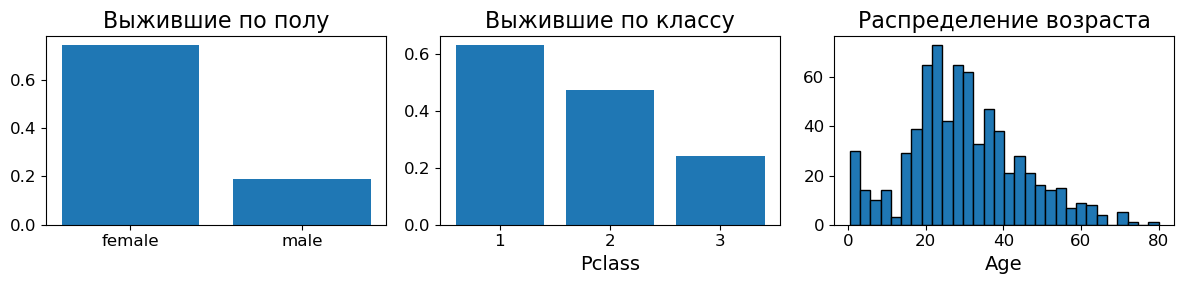

In [10]:
fig = plt.figure(figsize=(12, 3))

# Выжившие по полу
plt.subplot(1, 3, 1)
sex_stats = df.groupby('Sex')['Survived'].mean()
plt.bar(sex_stats.index, sex_stats.values)
plt.title('Выжившие по полу')

# Выжившие по классу
plt.subplot(1, 3, 2)
class_stats = df.groupby('Pclass')['Survived'].mean()
plt.bar(class_stats.index.astype(str), class_stats.values)
plt.title('Выжившие по классу')
plt.xlabel('Pclass')

# Распределение возраста
plt.subplot(1, 3, 3)
plt.hist(df['Age'].dropna(), bins=30, edgecolor='black')
plt.title('Распределение возраста')
plt.xlabel('Age')

plt.tight_layout()
plt.show()

### Построить интерактивный график со слайдером.

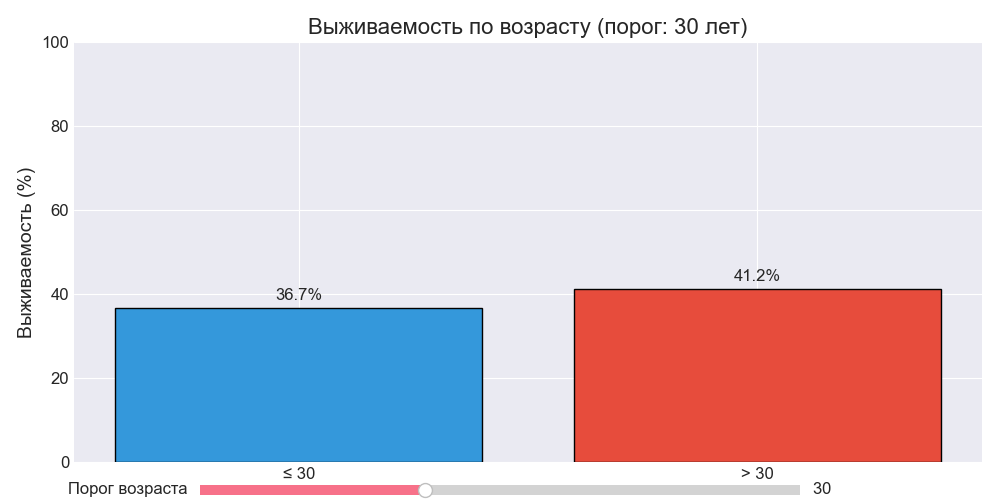

In [31]:
%matplotlib widget
from matplotlib.widgets import Slider

fig, ax = plt.subplots(figsize=(10, 5))
plt.subplots_adjust(bottom=0.5)

age_threshold = 30

def update(val):
    ax.clear()
    threshold = slider.val
    young = df[df['Age'] <= threshold]
    old = df[df['Age'] > threshold]
    
    young_surv = young['Survived'].mean() * 100
    old_surv = old['Survived'].mean() * 100
    
    ax.bar([f'≤ {threshold:.0f}', f'> {threshold:.0f}'], 
           [young_surv, old_surv], color=['#3498db', '#e74c3c'], edgecolor='black')
    ax.set_ylabel('Выживаемость (%)')
    ax.set_title(f'Выживаемость по возрасту (порог: {threshold} лет)')
    ax.set_ylim(0, 100)
    for i, v in enumerate([young_surv, old_surv]):
        ax.text(i, v + 2, f'{v:.1f}%', ha='center')
    fig.canvas.draw_idle()

slider_ax = plt.axes([0.2, 0.001, 0.6, 0.04])
slider = Slider(slider_ax, 'Порог возраста', 0, 80, valinit=age_threshold, valstep=1)
slider.on_changed(update)

update(age_threshold)
plt.tight_layout()
plt.show()

In [12]:
%matplotlib inline

## pandas

- Построить три разных вида графиков с использованием `pandas.DataFrame.plot` / `Series.plot`.  

> - Среди графиков должен присутствовать один `boxplot` (обязательно надо использовать параметр `by` для исследования взаимосвязи числовойпеременной и какой-либо другой).  
> - Графики должны быть построены как через методы `DataFrame`, так и через методы `Series`. То есть оба варианта нужно продемонстрировать.

### Построить три разных вида графиков с использованием pandas.DataFrame.plot / Series.plot.

#### Boxplot

<Figure size 1200x700 with 0 Axes>

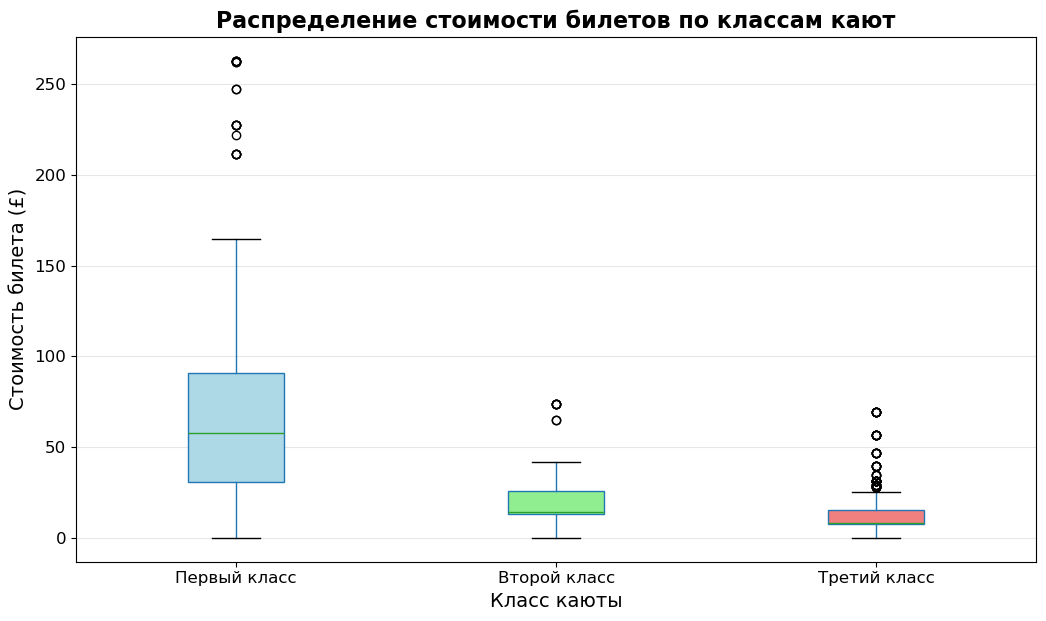

In [14]:
plt.figure(figsize=(12, 7))

# Подготовка данных - убираем нулевые и очень большие значения
fare_data = df[df['Fare'] < 300]  # Убираем выбросы

# Создаем boxplot
boxplot = fare_data.boxplot(column='Fare', by='Pclass', grid=False, 
                           patch_artist=True, figsize=(12, 7))

plt.suptitle('')  # Убираем автоматический заголовок
plt.title('Распределение стоимости билетов по классам кают', fontsize=16, fontweight='bold')
plt.xlabel('Класс каюты', fontsize=14)
plt.ylabel('Стоимость билета (£)', fontsize=14)
plt.xticks([1, 2, 3], ['Первый класс', 'Второй класс', 'Третий класс'])

# Раскрашиваем boxplot
colors = ['lightblue', 'lightgreen', 'lightcoral']
for patch, color in zip(boxplot.findobj(plt.matplotlib.patches.PathPatch), colors):
    patch.set_facecolor(color)

plt.grid(axis='y', alpha=0.3)

plt.show()

####  DataFrame.plot: сгруппированная столбчатая диаграмма

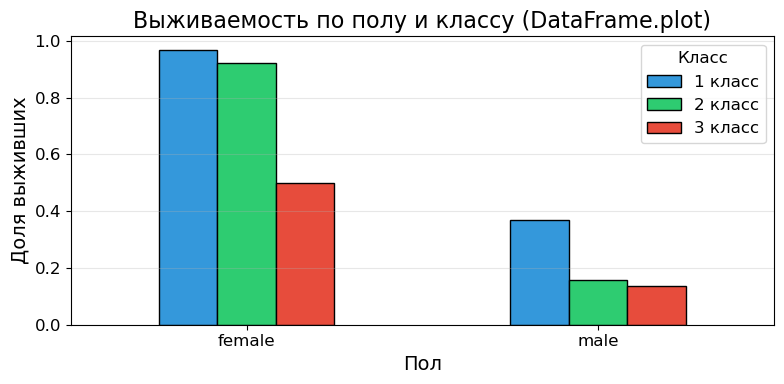

In [15]:
df_plot = df.groupby(['Sex', 'Pclass'])['Survived'].mean().unstack()

ax1 = df_plot.plot(kind='bar', figsize=(8, 4), rot=0, 
                   color=['#3498db', '#2ecc71', '#e74c3c'], edgecolor='black')
ax1.set_title('Выживаемость по полу и классу (DataFrame.plot)')
ax1.set_xlabel('Пол')
ax1.set_ylabel('Доля выживших')
ax1.legend(title='Класс', labels=['1 класс', '2 класс', '3 класс'])
ax1.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### Series.plot: график плотности распределения

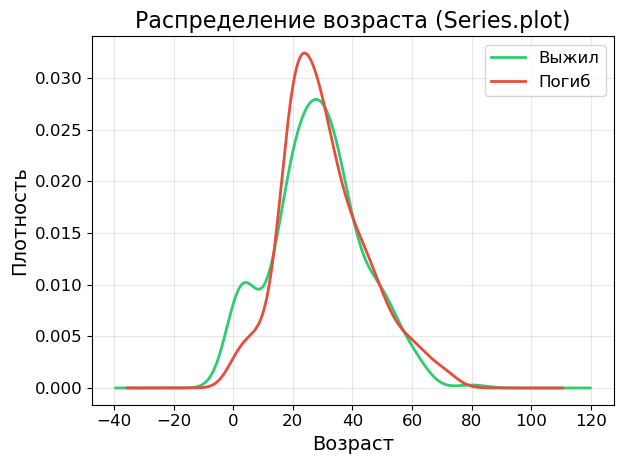

In [16]:
age_survived = df[df['Survived'] == 1]['Age'].dropna()
age_died = df[df['Survived'] == 0]['Age'].dropna()

ax2 = age_survived.plot(kind='kde', label='Выжил', color='#2ecc71', linewidth=2)
age_died.plot(kind='kde', label='Погиб', color='#e74c3c', linewidth=2, ax=ax2)

ax2.set_title('Распределение возраста (Series.plot)')
ax2.set_xlabel('Возраст')
ax2.set_ylabel('Плотность')
ax2.legend()
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## seaborn

- Построить `.pairplot` на каком-либо наборе данных, проанализировать взаимосвязь набора числовых признаков.  
- Построить `.jointplot`, проанализировать взаимосвязь двух конкретных числовых признаков.  
- Построить `.boxplot` и/или `.violinplot` на каком-либо наборе данных, проанализировать числовой признак в разрезе категориального.  
- Построить график `.heatmap` попарной корреляции всех числовых признаков.

  > Категориальные признаки необходимо убрать из датафрейма перед построением.  

In [17]:
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

### Построить .pairplot на каком-либо наборе данных, проанализировать взаимосвязь набора числовых признаков.

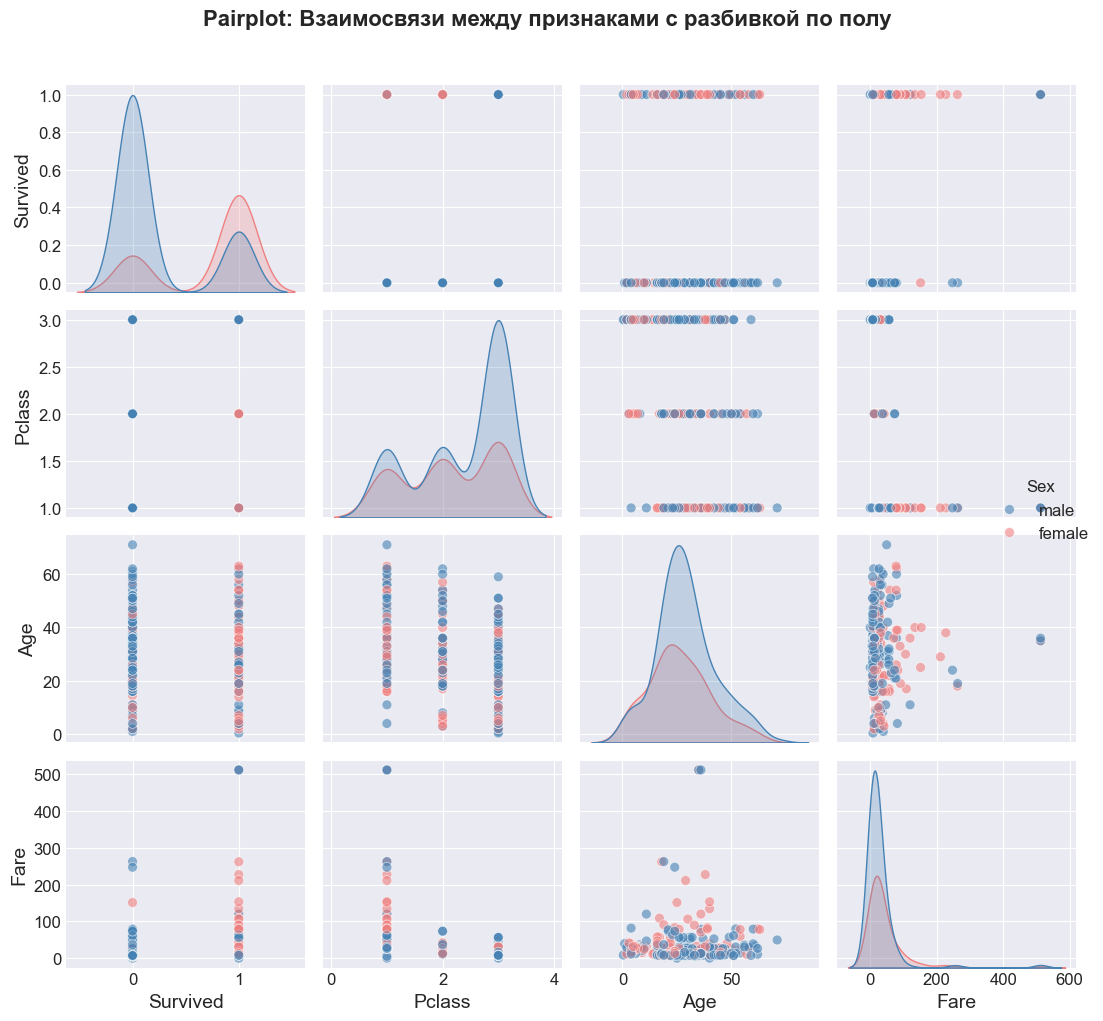

In [18]:
sample_df = df[['Survived', 'Pclass', 'Age', 'Fare', 'Sex']].dropna().sample(300, random_state=42)

pairplot = sns.pairplot(sample_df, hue='Sex', palette={'male': 'steelblue', 'female': 'lightcoral'},
                        diag_kind='kde', plot_kws={'alpha': 0.6, 's': 50},
                        height=2.5)

pairplot.fig.suptitle('Pairplot: Взаимосвязи между признаками с разбивкой по полу', 
                      fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

 Pairplot позволяет одновременно увидеть распределения отдельных переменных (на диагонали) и взаимосвязи между всеми парами переменных. На графике видно, как распределяются возраст и стоимость билета для мужчин и женщин, а также как эти переменные связаны между собой. Это отличный инструмент для первоначального исследования данных.

 Наиболее сильная взаимосвязь наблюдается между полом и выживаемостью: женщины (красные точки) демонстрируют значительно более высокую долю выживших по сравнению с мужчинами. Класс каюты (Pclass) также коррелирует с выживаемостью — пассажиры 1-го класса выживали чаще, при этом они платили существенно более высокие тарифы (Fare). Распределение тарифов сильно скошено: большинство пассажиров платили небольшие суммы, а высокие fares характерны преимущественно для 1-го класса. Возраст (Age) слабо коррелирует с другими признаками — распределение возрастов похоже во всех классах и среди выживших/погибших, хотя видно, что основная масса пассажиров была в возрасте 20-40 лет. 

### Построить .jointplot, проанализировать взаимосвязь двух конкретных числовых признаков.

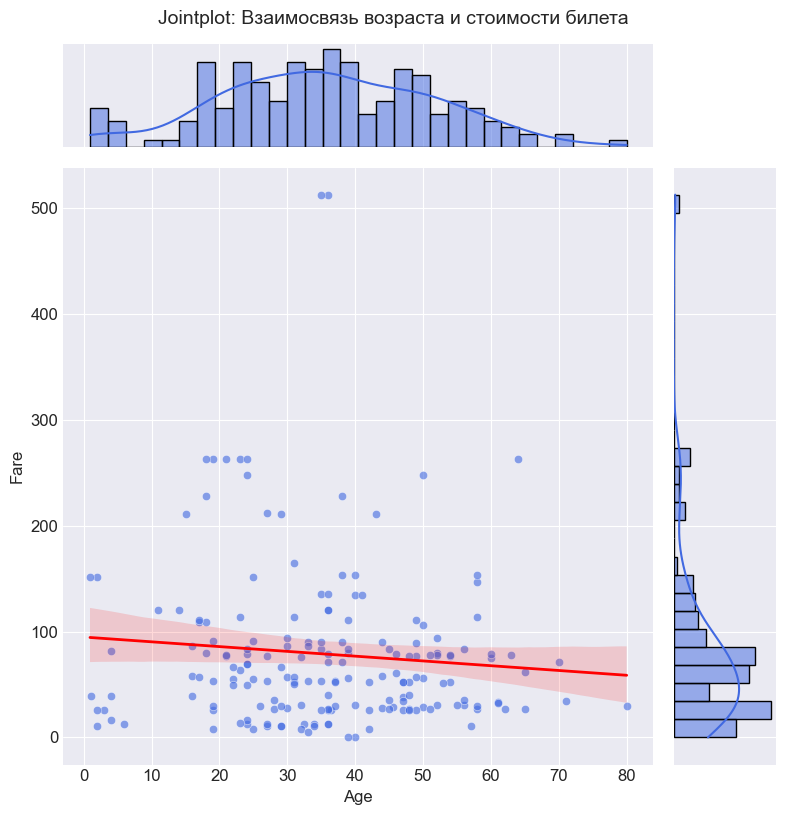

In [19]:
joint_grid = sns.jointplot(data=df.dropna(),
                           x='Age',
                           y='Fare',
                           kind='scatter',
                           height=8,
                           ratio=5,
                           space=0.2,
                           alpha=0.6,
                           color='royalblue',
                           marginal_kws={'bins': 30, 'kde': True})

joint_grid.ax_joint.set_xlabel('Возраст', fontsize=12)
joint_grid.ax_joint.set_ylabel('Стоимость билета', fontsize=12)
joint_grid.fig.suptitle('Jointplot: Взаимосвязь возраста и стоимости билета', 
                       y=1.02, fontsize=14)

sns.regplot(data=df.dropna(),
            x='Age',
            y='Fare',
            ax=joint_grid.ax_joint,
            scatter=False,
            color='red',
            line_kws={'linewidth': 2})

plt.show()

Между возрастом пассажиров (Age) и стоимостью билета (Fare) наблюдается слабая отрицательная корреляция: красная линия регрессии имеет небольшой нисходящий тренд, что указывает на тенденцию снижения цены билета с увеличением возраста. Однако связь выражена слабо — точки сильно разбросаны, а коэффициент детерминации низкий. Распределение возраста близко к нормальному с пиком около 30–40 лет, тогда как распределение тарифов сильно скошено вправо: большинство пассажиров платили менее 100 фунтов, а высокие тарифы (>200 фунтов) встречаются редко и являются выбросами. В целом, возраст не является значимым предиктором стоимости билета — цена определялась скорее классом каюты и другими факторами, а не возрастом пассажира.

### Построить .boxplot и/или .violinplot на каком-либо наборе данных, проанализировать числовой признак в разрезе категориального.

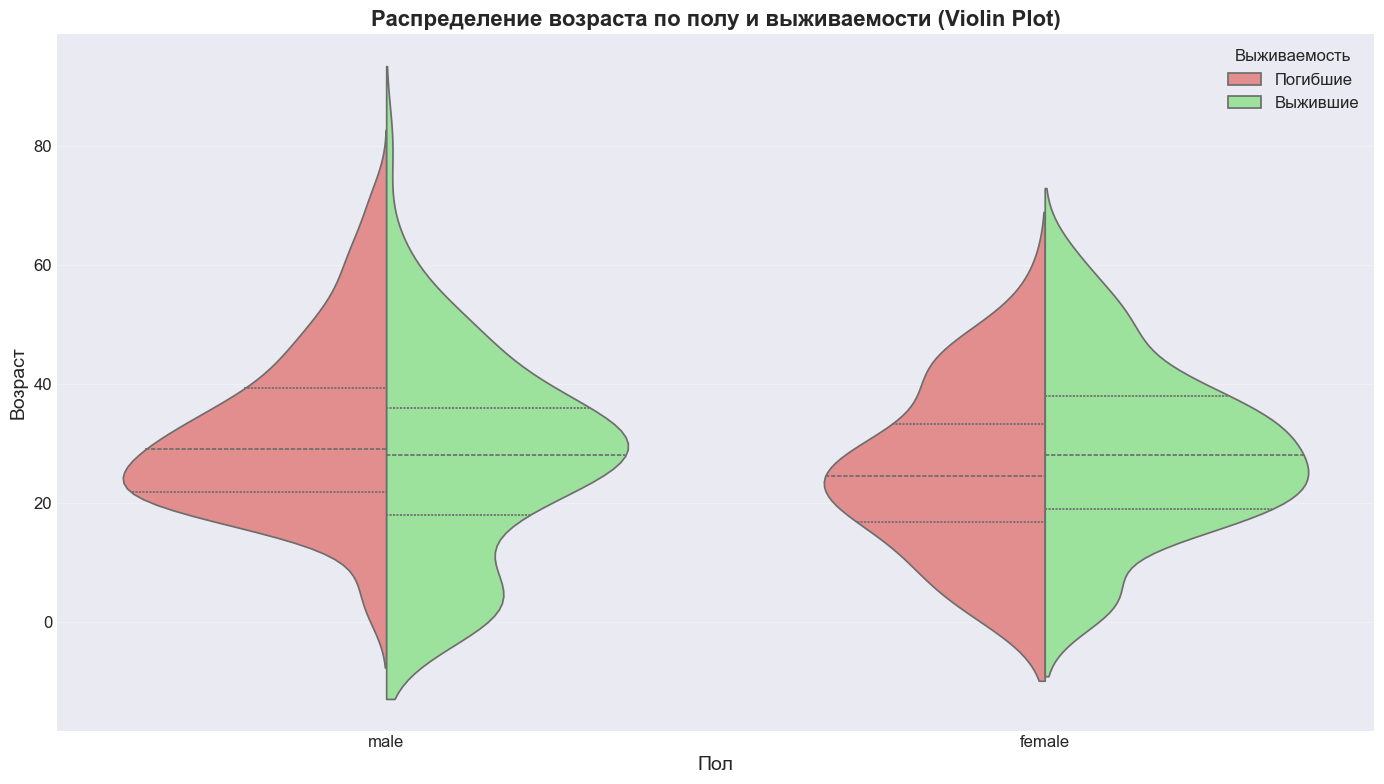

In [20]:
plt.figure(figsize=(14, 8))

# Подготовка данных
violin_data = df.dropna(subset=['Age', 'Sex', 'Survived'])

# Создаем violin plot
ax = sns.violinplot(x='Sex', y='Age', hue='Survived', data=violin_data,
                   split=True, inner="quart", palette={0: "lightcoral", 1: "lightgreen"})

plt.xlabel('Пол', fontsize=14)
plt.ylabel('Возраст', fontsize=14)
plt.title('Распределение возраста по полу и выживаемости (Violin Plot)', 
          fontsize=16, fontweight='bold')

# Настраиваем легенду
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Погибшие', 'Выжившие'], title='Выживаемость')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

Violin plot сочетает в себе box plot и ядерную оценку плотности. Он показывает не только медиану и квартили, но и форму распределения. Мы видим, что среди выживших женщин больше детей и молодых женщин, а среди погибших мужчин преобладают молодые и среднего возраста.

График наглядно демонстрирует, что пол оказался значительно более важным фактором выживания, чем возраст: у мужчин (male) красная область (погибшие) существенно превосходит зелёную (выжившие) практически во всех возрастных группах, особенно в диапазоне 20–40 лет, где наблюдается пик плотности пассажиров. У женщин (female) ситуация обратная — зелёная область доминирует, указывая на высокий уровень выживаемости независимо от возраста, хотя основная масса пассажиров также сосредоточена в возрасте 20–35 лет. Таким образом, несмотря на схожее распределение возрастов у обоих полов, вероятность выживания кардинально различалась: мужчины гибли массово, тогда как женщины выживали преимущественно, что подтверждает приоритетность пола над возрастным фактором для взрослых пассажиров.

### Построить график .heatmap попарной корреляции всех числовых признаков.

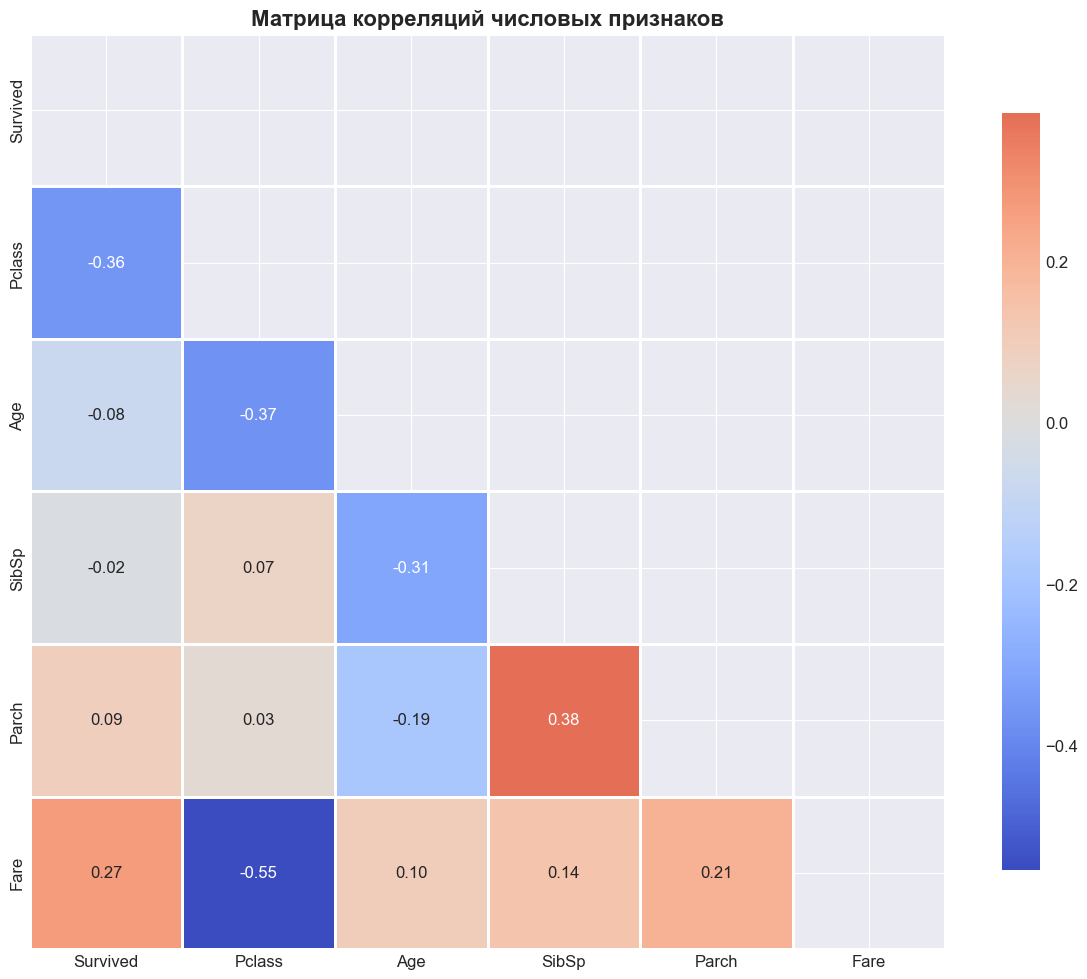

In [21]:
plt.figure(figsize=(12, 10))

# Выбираем числовые колонки
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
numeric_df = df[numeric_cols].dropna()

# Считаем корреляционную матрицу
corr_matrix = numeric_df.corr()

# Создаем heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Маска для верхнего треугольника

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, 
            cbar_kws={"shrink": 0.8}, mask=mask)

plt.title('Матрица корреляций числовых признаков', fontsize=16, fontweight='bold')
plt.tight_layout()

plt.show()

Heatmap корреляционной матрицы позволяет быстро оценить взаимосвязи между числовыми переменными. Самые сильные корреляции: отрицательная между классом каюты и выживаемостью (-0.34) и положительная между стоимостью билета и выживаемостью (0.26). Также видна ожидаемая сильная отрицательная корреляция между классом каюты и стоимостью билета (-0.55).

## scipy.stats

- Построить QQ-график (и гистограмму) для одного из числовых признаков с целью проверки на соответствие его распределения нормальному распределению. 

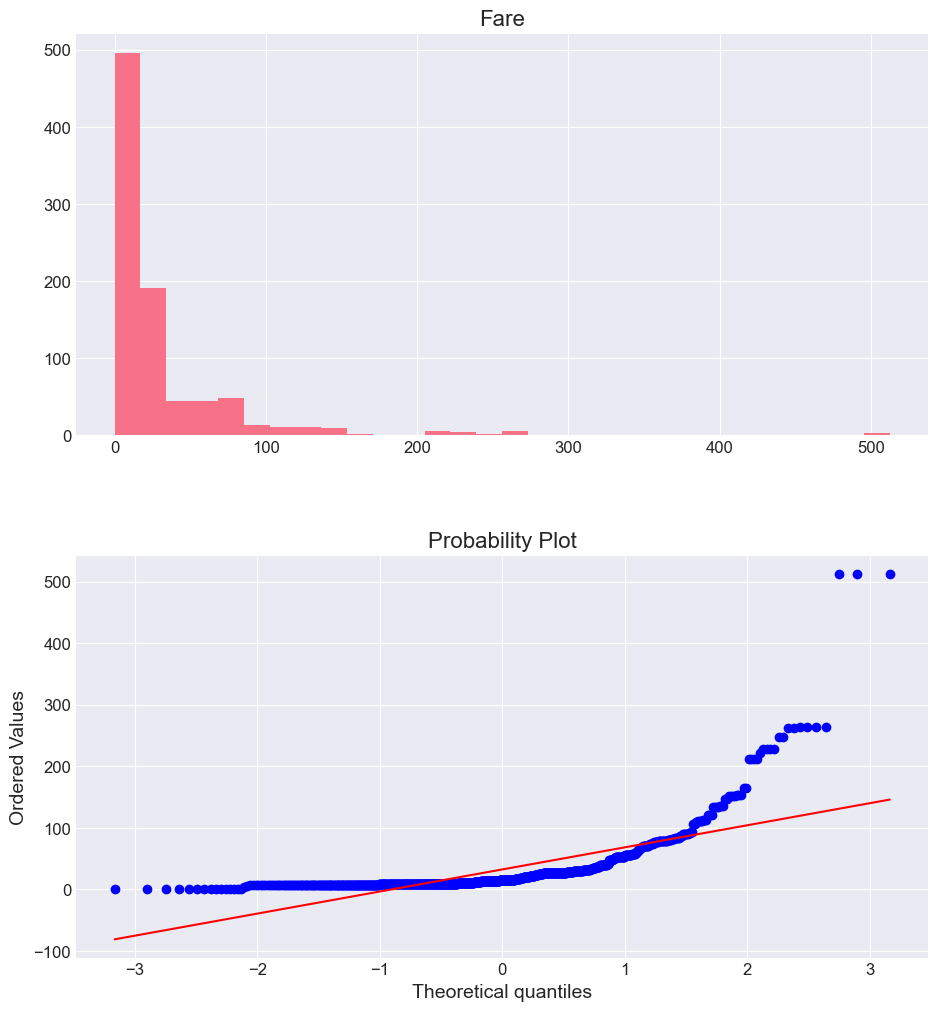

In [22]:
from scipy import stats

fig_p, ax_p = plt.subplots(2, 1, figsize=(11, 12))
stats.probplot( df['Fare'], dist="norm", plot=plt)
plt.subplot(2,1,2)
df.hist(ax = ax_p[0], column = 'Fare', bins = 30 )
plt.show()

## plotly

- Построить несколько графиков разного вида.  
- Построить несколько суб-графиков на одном графике.  
- Построить интерактивный график.  

  > Использование `Dash` опционально.

In [23]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [24]:
# Обработка данных
df['Age'] = df.groupby(['Sex', 'Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Создание категориальных переменных
df['Survived_label'] = df['Survived'].map({0: 'Погиб', 1: 'Выжил'})
df['Pclass_label'] = df['Pclass'].map({1: 'Первый', 2: 'Второй', 3: 'Третий'})
df['Embarked_label'] = df['Embarked'].map({'C': 'Шербур', 'Q': 'Квинстаун', 'S': 'Саутгемптон'})
df['Sex_label'] = df['Sex'].map({'male': 'Мужчина', 'female': 'Женщина'})

# Создаем дополнительные переменные для анимации и анализа
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 30, 50, 100], 
                        labels=['Ребенок', 'Подросток', 'Молодой', 'Взрослый', 'Пожилой'])
df['FareGroup'] = pd.qcut(df['Fare'], q=4, labels=['Низкая', 'Средняя', 'Высокая', 'Очень высокая'])

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived_label,Pclass_label,Embarked_label,Sex_label,FamilySize,AgeGroup,FareGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Погиб,Третий,Саутгемптон,Мужчина,2,Молодой,Низкая
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Выжил,Первый,Шербур,Женщина,2,Взрослый,Очень высокая
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Выжил,Третий,Саутгемптон,Женщина,1,Молодой,Средняя
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Выжил,Первый,Саутгемптон,Женщина,2,Взрослый,Очень высокая
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Погиб,Третий,Саутгемптон,Мужчина,1,Взрослый,Средняя


###  Построить несколько графиков разного вида.

#### Круговая диаграмма распределения выживших

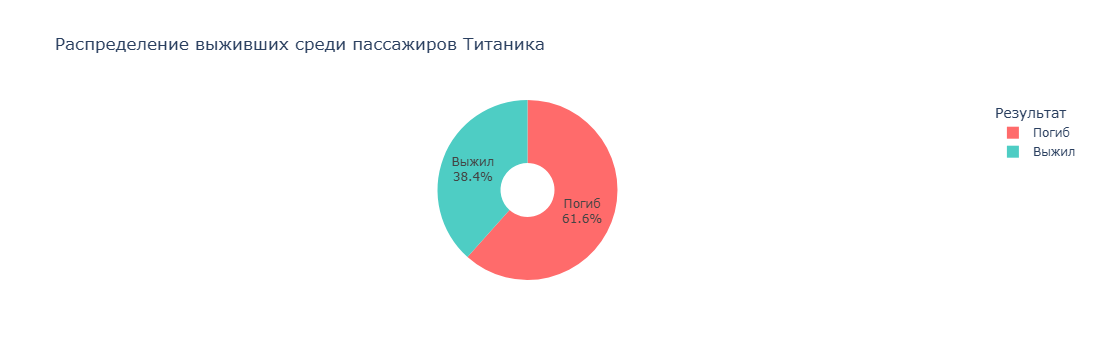

In [25]:
# Круговая диаграмма
fig1 = px.pie(df, 
              names='Survived_label',
              title='Распределение выживших среди пассажиров Титаника',
              color='Survived_label',
              color_discrete_map={'Погиб': '#ff6b6b', 'Выжил': '#4ecdc4'},
              hole=0.3)  # Добавляем отверстие для doughnut chart

fig1.update_traces(textposition='inside', textinfo='percent+label')
fig1.update_layout(showlegend=True, legend_title_text='Результат')
fig1.show()

#### Столбчатая диаграмма выживаемости по классам

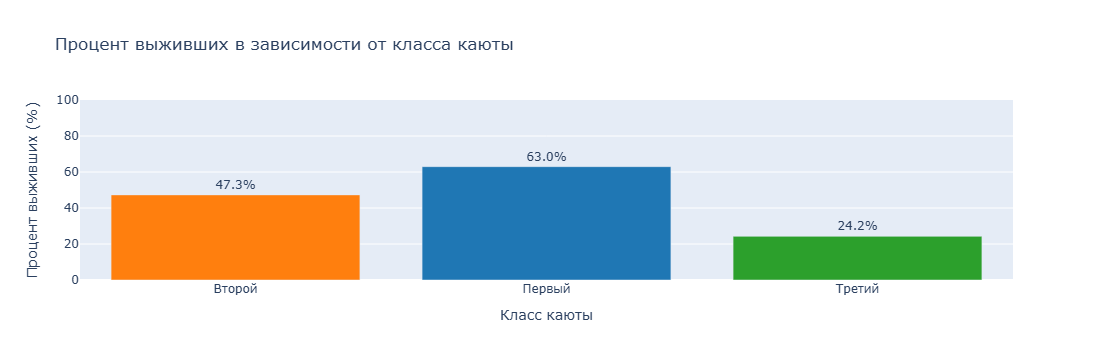

In [26]:
class_survival = df.groupby('Pclass_label')['Survived'].mean().reset_index()
class_survival['Процент'] = class_survival['Survived'] * 100

# Столбчатая диаграмма
fig2 = px.bar(class_survival, 
              x='Pclass_label', 
              y='Процент',
              title='Процент выживших в зависимости от класса каюты',
              color='Pclass_label',
              color_discrete_map={'Первый': '#1f77b4', 'Второй': '#ff7f0e', 'Третий': '#2ca02c'},
              text='Процент')

fig2.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig2.update_layout(xaxis_title='Класс каюты', 
                   yaxis_title='Процент выживших (%)',
                   showlegend=False)
fig2.update_yaxes(range=[0, 100])
fig2.show()

#### Диаграмма размаха (box plot) стоимости билетов по классам

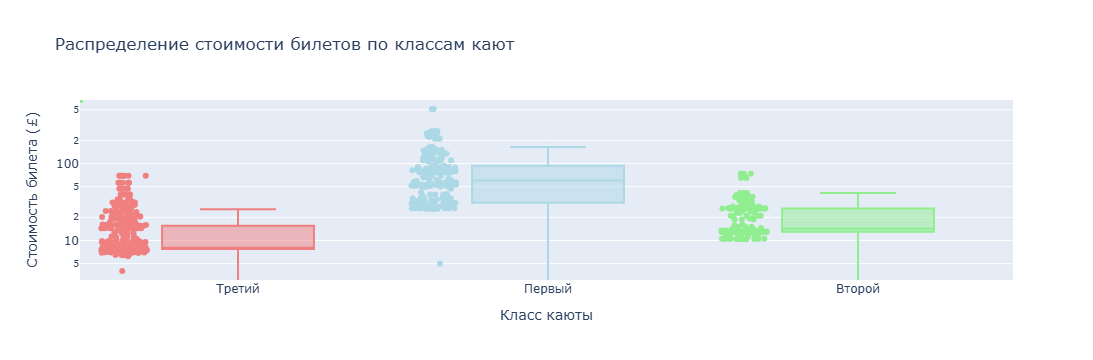

In [27]:
# Box plot с отображением выбросов
fig4 = px.box(df, 
              x='Pclass_label', 
              y='Fare',
              title='Распределение стоимости билетов по классам кают',
              color='Pclass_label',
              color_discrete_map={'Первый': 'lightblue', 'Второй': 'lightgreen', 'Третий': 'lightcoral'},
              points='all')  # 'all' показывает все точки, 'outliers' - только выбросы

fig4.update_layout(xaxis_title='Класс каюты', 
                   yaxis_title='Стоимость билета (£)',
                   showlegend=False)
fig4.update_yaxes(type="log")  # Логарифмическая шкала для обработки выбросов
fig4.show()

#### Группированная столбчатая диаграмма

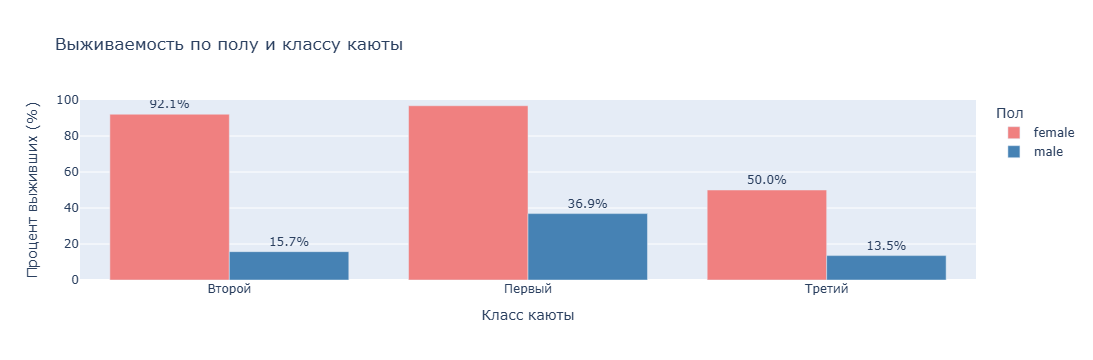

In [28]:
# Создаем сводную таблицу
pivot_data = df.groupby(['Sex', 'Pclass_label'])['Survived'].mean().reset_index()
pivot_data['Процент'] = pivot_data['Survived'] * 100

# Группированная столбчатая диаграмма
fig6 = px.bar(pivot_data, 
              x='Pclass_label', 
              y='Процент',
              color='Sex',
              barmode='group',
              title='Выживаемость по полу и классу каюты',
              color_discrete_map={'male': 'steelblue', 'female': 'lightcoral'},
              text='Процент')

fig6.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig6.update_layout(xaxis_title='Класс каюты', 
                   yaxis_title='Процент выживших (%)',
                   legend_title='Пол')
fig6.update_yaxes(range=[0, 100])
fig6.show()

### Построить несколько суб-графиков на одном графике.

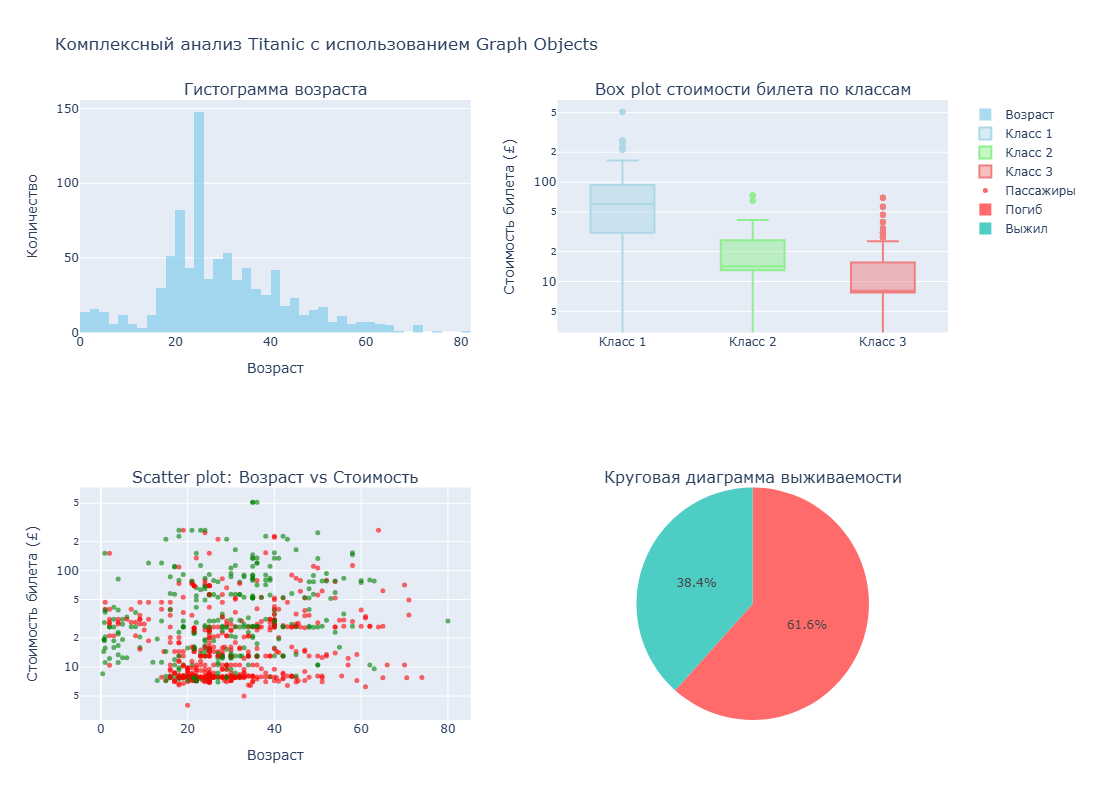

In [29]:
# Создаем фигуру с несколькими графиками
fig15 = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Гистограмма возраста', 
                    'Box plot стоимости билета по классам',
                    'Scatter plot: Возраст vs Стоимость',
                    'Круговая диаграмма выживаемости'),
    specs=[[{'type': 'histogram'}, {'type': 'box'}],
           [{'type': 'scatter'}, {'type': 'pie'}]]
)

# 1. Гистограмма возраста
fig15.add_trace(
    go.Histogram(x=df['Age'], name='Возраст', marker_color='skyblue', opacity=0.7),
    row=1, col=1
)

# 2. Box plot стоимости билета по классам
for pclass in sorted(df['Pclass'].unique()):
    class_data = df[df['Pclass'] == pclass]['Fare']
    fig15.add_trace(
        go.Box(y=class_data, name=f'Класс {pclass}', 
               marker_color=['lightblue', 'lightgreen', 'lightcoral'][pclass-1]),
        row=1, col=2
    )

# 3. Scatter plot: Возраст vs Стоимость
survived_colors = df['Survived'].map({0: 'red', 1: 'green'})
fig15.add_trace(
    go.Scatter(x=df['Age'], y=df['Fare'],
               mode='markers',
               marker=dict(color=survived_colors, size=5, opacity=0.6),
               name='Пассажиры',
               text=df['Name'],
               hovertemplate='<b>%{text}</b><br>Возраст: %{x}<br>Стоимость: %{y}£<extra></extra>'),
    row=2, col=1
)

# 4. Круговая диаграмма выживаемости
survival_counts = df['Survived_label'].value_counts()
fig15.add_trace(
    go.Pie(labels=survival_counts.index, 
           values=survival_counts.values,
           marker_colors=['#ff6b6b', '#4ecdc4'],
           name='Выживаемость'),
    row=2, col=2
)

# Обновляем layout
fig15.update_layout(height=800, width=1000, 
                    title_text="Комплексный анализ Titanic с использованием Graph Objects",
                    showlegend=True)

# Обновляем оси
fig15.update_xaxes(title_text="Возраст", row=1, col=1)
fig15.update_yaxes(title_text="Количество", row=1, col=1)
fig15.update_yaxes(title_text="Стоимость билета (£)", type="log", row=1, col=2)
fig15.update_xaxes(title_text="Возраст", row=2, col=1)
fig15.update_yaxes(title_text="Стоимость билета (£)", type="log", row=2, col=1)

fig15.show()

### Построить интерактивный график

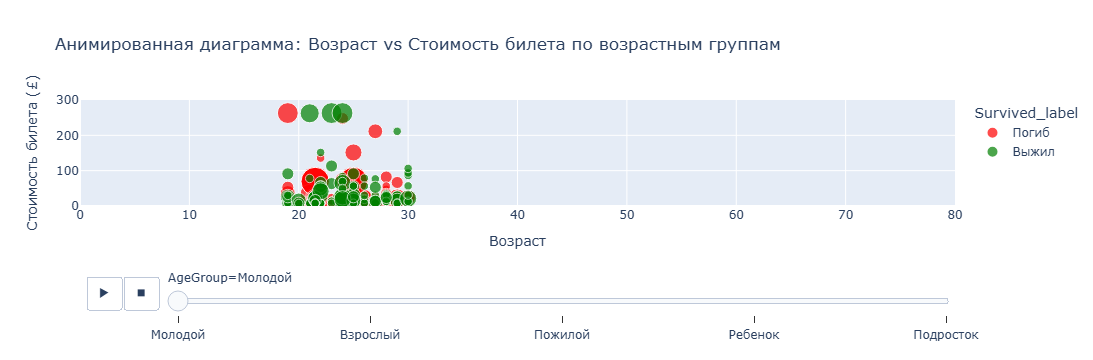

In [30]:
# Создаем анимированный scatter plot по возрастным группам
fig7 = px.scatter(df, 
                  x='Age', 
                  y='Fare',
                  color='Survived_label',
                  animation_frame='AgeGroup',  # Анимация по возрастным группам
                  animation_group='PassengerId',
                  size='FamilySize',  # Размер точки зависит от размера семьи
                  hover_name='Name',
                  title='Анимированная диаграмма: Возраст vs Стоимость билета по возрастным группам',
                  color_discrete_map={'Погиб': 'red', 'Выжил': 'green'},
                  range_x=[0, 80],
                  range_y=[0, 300])

fig7.update_layout(xaxis_title='Возраст', 
                   yaxis_title='Стоимость билета (£)')
fig7.show()